# Assignment 5 Solution

Backtest example strategy for the Swiss equity market.

In [ ]:
import os, sys
project_root = os.path.abspath('..')
sys.path.append(project_root)
sys.path.append(os.path.join(project_root, 'src'))
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from helper_functions import load_data_spi
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.optimization import MeanVariance
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest_item_builder_classes import SelectionItemBuilder, OptimizationItemBuilder
from backtesting.backtest_item_builder_functions import (
    bibfn_sector_upper_bounds,
    bibfn_selection_factor_zscore,
    bibfn_selection_min_volume,
    bibfn_selection_high_volatility, 
    bibfn_selection_quality,  
    bibfn_return_series,
    bibfn_predicted_returns,  # ML Prediction
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,                  
    bibfn_turnover_constraint,
)


## Load data

In [2]:

# Load market and factor data
market_data = pd.read_parquet('../data/market_data.parquet')
jkp_data = pd.read_parquet('../data/jkp_data.parquet')

# Load benchmark series (Swiss Performance Index)
bm_series = load_data_spi(path='../data/')

# Wrap data in BacktestData object
bt_data = BacktestData()
bt_data.market_data = market_data
bt_data.jkp_data = jkp_data
bt_data.bm_series = bm_series


## Set up backtest service

In [3]:

# Instantiate expected return and covariance models
expected_return = ExpectedReturn(method='geometric')
covariance = Covariance(method='pearson')

# Rebalancing dates (quarterly)
dates = market_data.index.get_level_values('date').unique().sort_values()
rebdates = dates[dates > '2010-01-01'][::63].strftime('%Y-%m-%d').tolist()

# Selection builders
selection_item_builders = {
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=252,
        min_volume=500000,
    ),  # Selection requirement
    'volatility': SelectionItemBuilder(
        bibfn=bibfn_selection_high_volatility,
        width=252,
        threshold=0.04,
    ),  # Selection requirement
    'quality': SelectionItemBuilder(
        bibfn=bibfn_selection_quality,
        field='qmj',
        threshold=0.0,
    ),  # Selection requirement
}



# Optimization item builders
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(bibfn=bibfn_return_series, width=252),
    'predicted': OptimizationItemBuilder(bibfn=bibfn_predicted_returns, width=1260),  # ML Prediction requirement
    'budget_constraint': OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
    'box_constraints': OptimizationItemBuilder(bibfn=bibfn_box_constraints, upper=0.1),
    'size_bounds': OptimizationItemBuilder(bibfn=bibfn_size_dependent_upper_bounds),
    'turnover_constraint': OptimizationItemBuilder(bibfn=bibfn_turnover_constraint, turnover_limit=0.25),
}



# 注册 sector 上限
optimization_item_builders["sector_bounds"] = OptimizationItemBuilder(
    bibfn=bibfn_sector_upper_bounds,
    sector_upper=0.25,
    item_name="sector_bounds"
)

# 注册 z-score 动量选股器
selection_item_builders["momentum_zscore"] = SelectionItemBuilder(
    bibfn=bibfn_selection_factor_zscore,
    field="ret_6_1",
    threshold=1.0,
    item_name="momentum_zscore"
)

# # 注册 z-score 价值选股器
# selection_item_builders["value_zscore"] = SelectionItemBuilder(
#     bibfn=bibfn_selection_factor_zscore,
#     field="ep",
#     threshold=1.0,
#     item_name="value_zscore"
# )

# Create backtest service
test_service = BacktestService(
    data=bt_data,
    optimization_item_builders=optimization_item_builders,
    selection_item_builders=selection_item_builders,
    rebdates=rebdates,
    optimization=MeanVariance(
        expected_return=expected_return,
        covariance=covariance,
        risk_aversion=1,
        solver_name='cvxopt',
    ),
)


In [5]:
def run_backtest_robust(bt_service, rebdates, strategy=None, verbose=True):
    """
    执行带容错机制的回测。若某 rebalance 日期无法构建或优化失败，则跳过该日期。

    参数:
        bt_service: BacktestService 实例
        rebdates: 需要回测的 rebalancing 日期列表
        strategy: 自定义 Strategy 类（可选）
        verbose: 是否打印运行状态
    """
    nav_series = []
    failed_rebdates = []

    for rebdate in rebdates:
        try:
            if verbose:
                print(f"\n🔁 Rebalancing on {rebdate}")

            # Step 1: 构建选股
            bt_service.build_selection(rebdate)

            # Step 2: 检查是否有足够资产
            if len(bt_service.selection.selected) < 3:
                raise ValueError("Too few assets selected.")

            # Step 3: 构建优化器（可能报错）
            bt_service.build_optimization(rebdate, strategy=strategy)

            # Step 4: 求解优化问题（核心步骤）
            bt_service.solve_optimization()

            # Step 5: 更新组合权重与 NAV
            bt_service.update_portfolio(rebdate)
            nav_series.append(bt_service.portfolio_nav.loc[rebdate])

        except Exception as e:
            print(f"⚠️ Skipped {rebdate} due to error: {e}")
            failed_rebdates.append(rebdate)
            continue

    if verbose:
        print(f"\n✅ Backtest complete. Skipped {len(failed_rebdates)} dates.")
    return bt_service.portfolio_nav, failed_rebdates


In [6]:
bt = BacktestService(
    data=bt_data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    expected_return=expected_return,
    covariance=covariance,
)

# 使用 wrapper 执行回测
strategy_nav, skipped_dates = run_backtest_robust(bt, rebdates)

# 可视化结果
strategy_nav.plot(title="Portfolio NAV (Robust Backtest)", figsize=(12,6))



🔁 Rebalancing on 2010-01-04


/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/backtest_item_builder_functions.py:478: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(horizon).shift(-horizon)


⚠️ Skipped 2010-01-04 due to error: 'EmptyOptimization' object has no attribute 'expected_return'

🔁 Rebalancing on 2010-04-01
⚠️ Skipped 2010-04-01 due to error: Too few assets selected.

🔁 Rebalancing on 2010-06-29
⚠️ Skipped 2010-06-29 due to error: Too few assets selected.

🔁 Rebalancing on 2010-09-24
⚠️ Skipped 2010-09-24 due to error: Too few assets selected.

🔁 Rebalancing on 2010-12-22


/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/backtest_item_builder_functions.py:478: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(horizon).shift(-horizon)


⚠️ Skipped 2010-12-22 due to error: 'EmptyOptimization' object has no attribute 'expected_return'

🔁 Rebalancing on 2011-03-21


...

⚠️ Skipped 2023-04-17 due to error: 'EmptyOptimization' object has no attribute 'expected_return'

🔁 Rebalancing on 2023-07-13


/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/backtest_item_builder_functions.py:478: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(horizon).shift(-horizon)


⚠️ Skipped 2023-07-13 due to error: 'EmptyOptimization' object has no attribute 'expected_return'

🔁 Rebalancing on 2023-10-10
⚠️ Skipped 2023-10-10 due to error: Too few assets selected.

🔁 Rebalancing on 2024-01-05
⚠️ Skipped 2024-01-05 due to error: Too few assets selected.

🔁 Rebalancing on 2024-04-03
⚠️ Skipped 2024-04-03 due to error: 'EmptyOptimization' object has no attribute 'expected_return'

✅ Backtest complete. Skipped 60 dates.


/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/backtest_item_builder_functions.py:478: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(horizon).shift(-horizon)


AttributeError: 'BacktestService' object has no attribute 'portfolio_nav'

## Run backtest

In [4]:

from backtesting.backtest import Backtest

bt = Backtest()
bt.run(test_service)


Rebalancing date: 2010-01-04


/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/backtest_item_builder_functions.py:478: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(horizon).shift(-horizon)


RuntimeError: domain error

## Simulate portfolio

/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
/Users/zihanliu/Documents/Github/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


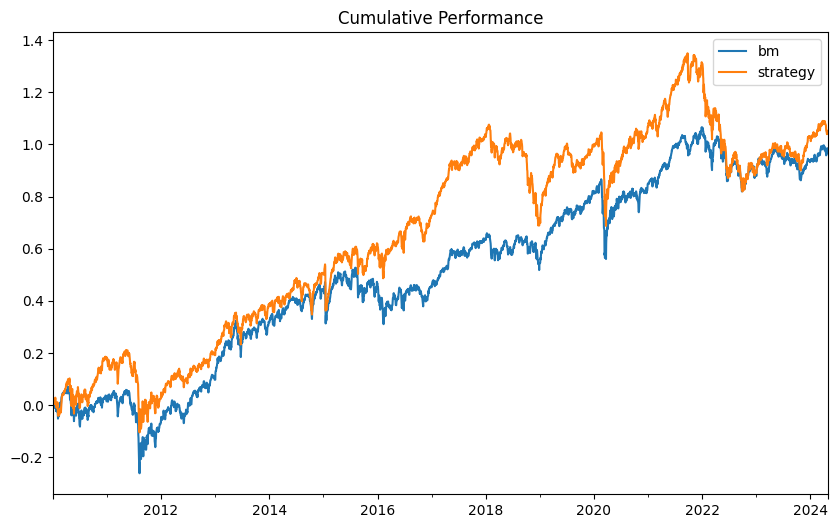

In [11]:

# Combine strategy returns with benchmark
returns = bt.strategy.simulate(
    return_series=test_service.data.get_return_series(),
    fc=0.01,  # Simulation requirement: fixed cost 1% p.a.
    vc=0.002,  # Simulation requirement: transaction cost 0.2% per rebalance
)

sim = pd.concat({'bm': bm_series, 'strategy': returns}, axis=1).dropna()

(np.log1p(sim)).cumsum().plot(title='Cumulative Performance', figsize=(10,6))
plt.show()


## Performance statistics

In [12]:

def perf_stats(x):
    ann_ret = np.exp(np.log1p(x).mean()*252)-1
    ann_vol = x.std()*np.sqrt(252)
    sharpe = ann_ret/ann_vol
    cum_ret = (1+x).prod()-1
    running = (1+x).cumprod()
    peak = running.cummax()
    drawdown = running/peak -1
    max_dd = drawdown.min()
    return pd.Series({'annual_return':ann_ret,'annual_volatility':ann_vol,'sharpe':sharpe,'cumulative_return':cum_ret,'max_drawdown':max_dd})

stats = sim.apply(perf_stats)
print(stats)


                         bm  strategy
annual_return      0.067722  0.073126
annual_volatility  0.144168  0.162212
sharpe             0.469743  0.450802
cumulative_return  1.641824  1.847130
max_drawdown      -0.282289 -0.411041
